# Research Thermal Stress & Sound Pollution

### Urban heat islands effects
### Longer duration of heat events

In [1]:
import pandas as pd
import datetime
import numpy as np
import matplotlib.pyplot as plt

import ee
print(ee.__version__)
ee.Authenticate()  # Regular auth — follow the link and paste the token
ee.Initialize(project='utility-realm-255220')

1.5.21


In [2]:
import geemap
geemap.ee_initialize()

In [6]:
# Define your bounding box (Allen, TX area)
bbox = ee.Geometry.BBox(-96.7140, 33.0700, -96.6240, 33.1400)

# Load DAYMET daily max temperature dataset
dataset = ee.ImageCollection("NASA/ORNL/DAYMET_V4") \
             .select("tmax") \
             .filterBounds(bbox) \
             .filterDate('1980-01-01', '2023-12-31')


In [11]:
# Define years
years = list(range(1981, 2024))

def count_hot_days(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, 'year')

    # Filter to this year
    year_imgs = dataset.filterDate(start, end)

    # Create binary mask: 1 where tmax > 35°C
    hot_days = year_imgs.map(lambda img: img.gt(35).copyProperties(img, img.propertyNames()))

    # Sum all hot days
    summed = hot_days.sum().reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=bbox,
        scale=1000,
        maxPixels=1e9
    ).get('tmax')

    return ee.Feature(None, {'year': year, 'hot_days': summed})

# Create feature collection
hot_day_fc = ee.FeatureCollection([count_hot_days(y) for y in years])


The variability is large, with big year-to-year swing.

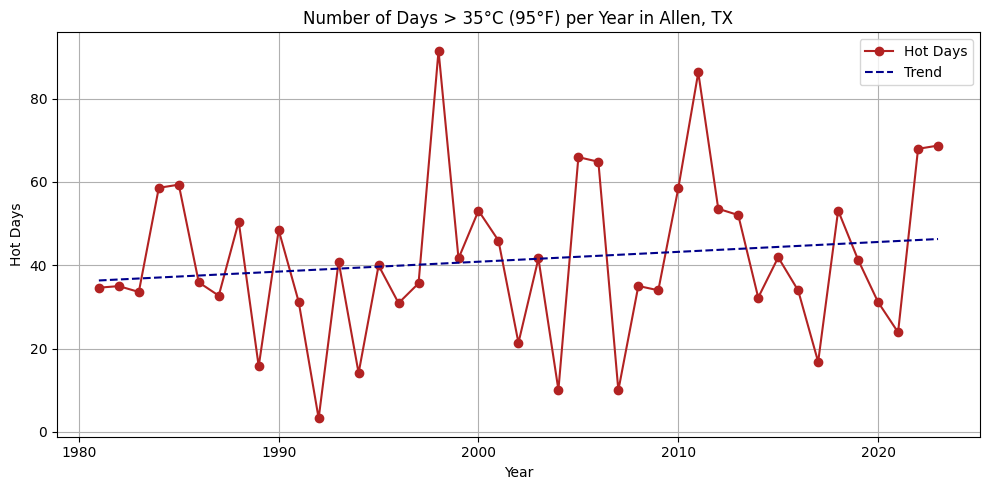

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Build dataframe
hot_days_dict = hot_day_fc.aggregate_array('hot_days').getInfo()
year_values = years
df = pd.DataFrame({
    'Year': year_values,
    'Hot_Days_Above_35C': hot_days_dict
})

# Linear regression for trendline
X = df['Year'].values.reshape(-1, 1)
y = df['Hot_Days_Above_35C'].values
model = LinearRegression().fit(X, y)
trend = model.predict(X)

# Plot: start figure before plotting
plt.figure(figsize=(10,5))
plt.plot(df['Year'], y, 'o-', color='firebrick', label='Hot Days')
plt.plot(df['Year'], trend, '--', color='darkblue', label='Trend')

# Style
plt.title('Number of Days > 35°C (95°F) per Year in Allen, TX')
plt.xlabel('Year')
plt.ylabel('Hot Days')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

5-Year rolling average

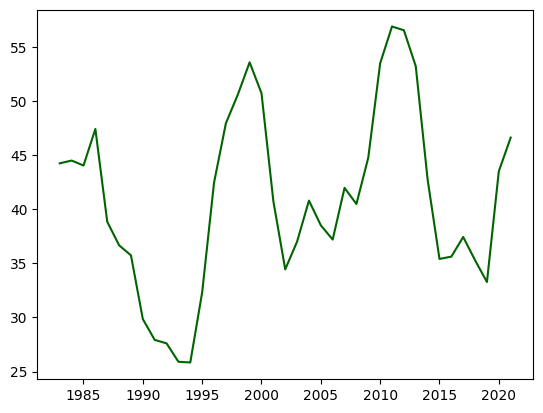

In [20]:
df['Rolling5'] = df['Hot_Days_Above_35C'].rolling(window=5, center=True).mean()
plt.plot(df['Year'], df['Rolling5'], label='5-Year Avg', color='darkgreen');

reduceRegion(..., reducer=ee.Reducer.mean())
This doesn't just count hot days.

It averages the number of hot days per pixel across your entire bounding box.

If one pixel had 20 hot days and another had 10, the mean is (20 + 10)/2 = 15.0.

If some pixels are partially hot (due to resampling, interpolation, or fractional coverage), it may yield non-integers like 15.37.

In [13]:
df

,Year,Hot_Days_Above_35C
0,1981,34.629255
1,1982,35.003182
2,1983,33.602081
3,1984,58.589605
4,1985,59.348672
5,1986,35.906556
6,1987,32.709718
7,1988,50.476361
8,1989,15.757147
9,1990,48.450197


## Validating Urban Heat Islands

UHI is the phenomenon where urban area experience significantly higher temperature than surrounding rural areas, especially during the nighttime.

>6 degree difference strongly suggests the Allen, despite not being at a dense urban core, exhibits significant urban heat island behavior.

https://climatekids.nasa.gov/heat-islands/

MOD11A2.061 Terra Land Surface Temperature and Emissivity 8-Day Global 1km

https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD11A2

https://en.wikipedia.org/wiki/Urban_heat_island


| Feature                 | Value                                               |
| ----------------------- | --------------------------------------------------- |
| **Dataset Name**        | MODIS Terra Land Surface Temperature and Emissivity |
| **Earth Engine ID**     | `MODIS/061/MOD11A2`                                 |
| **Spatial Resolution**  | \~1 km                                              |
| **Temporal Resolution** | 8-day composites                                    |
| **Time Coverage**       | 2000–present                                        |
| **Source**              | Terra MODIS sensor (NASA)                           |


Key Temperature Bands
- LDT_Day_1km: Daytime land surface temperature
- LST_Night_1km: Nighttime land surface temperature


In [25]:
# Create interactive map centered near Allen/Dallas
Map = geemap.Map(center=[33.0, -96.7], zoom=9)

# Define Allen, TX
allen_bbox = ee.Geometry.BBox(-96.7140, 33.0700, -96.6240, 33.1400)
allen_fc = ee.FeatureCollection([ee.Feature(allen_bbox, {'name': 'Allen'})])
Map.addLayer(allen_fc.style(color='red', fillColor='00000000', width=2), {}, 'Allen')

# Define Rural Area (Lucas/Lavon Lake)
rural_bbox = ee.Geometry.BBox(-96.5600, 33.0800, -96.4700, 33.1500)
rural_fc = ee.FeatureCollection([ee.Feature(rural_bbox, {'name': 'Rural'})])
Map.addLayer(rural_fc.style(color='green', fillColor='00000000', width=2), {}, 'Rural Reference')

# Define Downtown Dallas Bounding Box (approximate)
dallas_bbox = ee.Geometry.BBox(-96.8170, 32.7680, -96.7830, 32.8030)
dallas_fc = ee.FeatureCollection([ee.Feature(dallas_bbox, {'name': 'Dallas'})])
Map.addLayer(dallas_fc.style(color='blue', fillColor='00000000', width=2), {}, 'Downtown Dallas')

# Show the map
Map

Map(center=[33.0, -96.7], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

In [26]:
# Define bounding boxes
allen_bbox = ee.Geometry.BBox(-96.7140, 33.0700, -96.6240, 33.1400)
rural_bbox = ee.Geometry.BBox(-96.5600, 33.0800, -96.4700, 33.1500)
dallas_bbox = ee.Geometry.BBox(-96.8170, 32.7680, -96.7830, 32.8030)  # Approximate downtown Dallas

# Load MODIS LST Daytime data (convert to °C)
modis = ee.ImageCollection("MODIS/061/MOD11A2") \
           .select('LST_Day_1km') \
           .filterDate('2023-06-01', '2023-08-31') \
           .map(lambda img: img.multiply(0.02).subtract(273.15).copyProperties(img, img.propertyNames()))

# Mean LST for Allen
allen_mean = modis.mean().reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=allen_bbox,
    scale=1000,
    maxPixels=1e9
).get('LST_Day_1km')

# Mean LST for Rural Area
rural_mean = modis.mean().reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=rural_bbox,
    scale=1000,
    maxPixels=1e9
).get('LST_Day_1km')

# Mean LST for Downtown Dallas
dallas_mean = modis.mean().reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=dallas_bbox,
    scale=1000,
    maxPixels=1e9
).get('LST_Day_1km')

# Get values to client
allen_temp = allen_mean.getInfo()
rural_temp = rural_mean.getInfo()
dallas_temp = dallas_mean.getInfo()

# Compute UHI Intensities
allen_uhi = allen_temp - rural_temp
dallas_uhi = dallas_temp - rural_temp

# Print results
print(f"Allen Summer 2023 Mean LST: {allen_temp:.2f}°C")
print(f"Dallas Summer 2023 Mean LST: {dallas_temp:.2f}°C")
print(f"Rural Area Mean LST: {rural_temp:.2f}°C")
print(f"Allen UHI Intensity: {allen_uhi:.2f}°C")
print(f"Dallas UHI Intensity: {dallas_uhi:.2f}°C")


Allen Summer 2023 Mean LST: 39.74°C
Dallas Summer 2023 Mean LST: 40.98°C
Rural Area Mean LST: 33.65°C
Allen UHI Intensity: 6.09°C
Dallas UHI Intensity: 7.33°C


In [23]:
# Load MODIS Land Surface Temperature (in Kelvin)
modis = ee.ImageCollection("MODIS/061/MOD11A2") \
           .select('LST_Night_1km') \
           .filterDate('2023-06-01', '2023-08-31') \
           .map(lambda img: img.multiply(0.02).subtract(273.15).copyProperties(img, img.propertyNames()))  # Convert K to °C

# Mean LST for Allen
allen_mean = modis.mean().reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=allen_bbox,
    scale=1000,
    maxPixels=1e9
).get('LST_Night_1km')

# Mean LST for rural reference area
rural_mean = modis.mean().reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=rural_bbox,
    scale=1000,
    maxPixels=1e9
).get('LST_Night_1km')

# Compute UHI Intensity
allen_temp = allen_mean.getInfo()
rural_temp = rural_mean.getInfo()

uhi_intensity = allen_temp - rural_temp

print(f"Allen Summer 2023 Mean LST: {allen_temp:.2f}°C")
print(f"Rural Area Mean LST: {rural_temp:.2f}°C")
print(f"Estimated UHI Intensity: {uhi_intensity:.2f}°C")


Allen Summer 2023 Mean LST: 27.21°C
Rural Area Mean LST: 25.89°C
Estimated UHI Intensity: 1.31°C


In [27]:
# Define bounding boxes
allen_bbox = ee.Geometry.BBox(-96.7140, 33.0700, -96.6240, 33.1400)
rural_bbox = ee.Geometry.BBox(-96.5600, 33.0800, -96.4700, 33.1500)
dallas_bbox = ee.Geometry.BBox(-96.8170, 32.7680, -96.7830, 32.8030)  # Approximate downtown Dallas

# Load MODIS LST Daytime data (convert to °C)
modis = ee.ImageCollection("MODIS/061/MOD11A2") \
           .select('LST_Night_1km') \
           .filterDate('2023-06-01', '2023-08-31') \
           .map(lambda img: img.multiply(0.02).subtract(273.15).copyProperties(img, img.propertyNames()))

# Mean LST for Allen
allen_mean = modis.mean().reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=allen_bbox,
    scale=1000,
    maxPixels=1e9
).get('LST_Night_1km')

# Mean LST for Rural Area
rural_mean = modis.mean().reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=rural_bbox,
    scale=1000,
    maxPixels=1e9
).get('LST_Night_1km')

# Mean LST for Downtown Dallas
dallas_mean = modis.mean().reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=dallas_bbox,
    scale=1000,
    maxPixels=1e9
).get('LST_Night_1km')

# Get values to client
allen_temp = allen_mean.getInfo()
rural_temp = rural_mean.getInfo()
dallas_temp = dallas_mean.getInfo()

# Compute UHI Intensities
allen_uhi = allen_temp - rural_temp
dallas_uhi = dallas_temp - rural_temp

# Print results
print(f"Allen Summer 2023 Mean LST: {allen_temp:.2f}°C")
print(f"Dallas Summer 2023 Mean LST: {dallas_temp:.2f}°C")
print(f"Rural Area Mean LST: {rural_temp:.2f}°C")
print(f"Allen UHI Intensity: {allen_uhi:.2f}°C")
print(f"Dallas UHI Intensity: {dallas_uhi:.2f}°C")


Allen Summer 2023 Mean LST: 27.21°C
Dallas Summer 2023 Mean LST: 29.21°C
Rural Area Mean LST: 25.89°C
Allen UHI Intensity: 1.31°C
Dallas UHI Intensity: 3.31°C


In [46]:
# import ee
import pandas as pd
import matplotlib.pyplot as plt
# ee.Initialize()

# Define bounding boxes
allen_bbox = ee.Geometry.BBox(-96.7140, 33.0700, -96.6240, 33.1400)
rural_bbox = ee.Geometry.BBox(-96.5600, 33.0800, -96.4700, 33.1500)
dallas_bbox = ee.Geometry.BBox(-96.8170, 32.7680, -96.7830, 32.8030)

# Function to get mean summer LST for a given year, geometry, and band
def get_mean_lst(year, geometry, band_name):
    start = ee.Date.fromYMD(year, 6, 1)
    end = start.advance(3, 'month')

    collection = ee.ImageCollection("MODIS/061/MOD11A2") \
        .select(band_name) \
        .filterDate(start, end) \
        .map(lambda img: img.multiply(0.02).subtract(273.15).multiply(9/5).add(32).copyProperties(img, img.propertyNames()))


    mean = collection.mean().reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geometry,
        scale=1000,
        maxPixels=1e9
    ).get(band_name)

    return mean

# Loop through years and collect data
years = list(range(2001, 2025))
data = []

for year in years:
    # Day LST
    allen_day = get_mean_lst(year, allen_bbox, 'LST_Day_1km').getInfo()
    dallas_day = get_mean_lst(year, dallas_bbox, 'LST_Day_1km').getInfo()
    rural_day = get_mean_lst(year, rural_bbox, 'LST_Day_1km').getInfo()

    # Night LST
    allen_night = get_mean_lst(year, allen_bbox, 'LST_Night_1km').getInfo()
    dallas_night = get_mean_lst(year, dallas_bbox, 'LST_Night_1km').getInfo()
    rural_night = get_mean_lst(year, rural_bbox, 'LST_Night_1km').getInfo()

    # Store in data table
    data.append({
        'Year': year,
        'Allen_Day': allen_day,
        'Dallas_Day': dallas_day,
        'Rural_Day': rural_day,
        'Allen_Night': allen_night,
        'Dallas_Night': dallas_night,
        'Rural_Night': rural_night,
        'Allen_UHI_Day': allen_day - rural_day,
        'Dallas_UHI_Day': dallas_day - rural_day,
        'Allen_UHI_Night': allen_night - rural_night,
        'Dallas_UHI_Night': dallas_night - rural_night
    })

# Create DataFrame
df = pd.DataFrame(data)



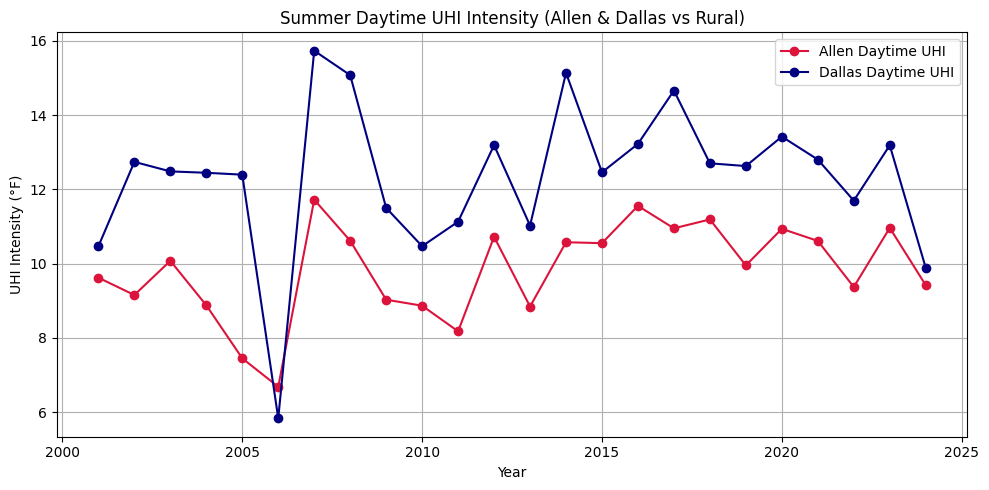

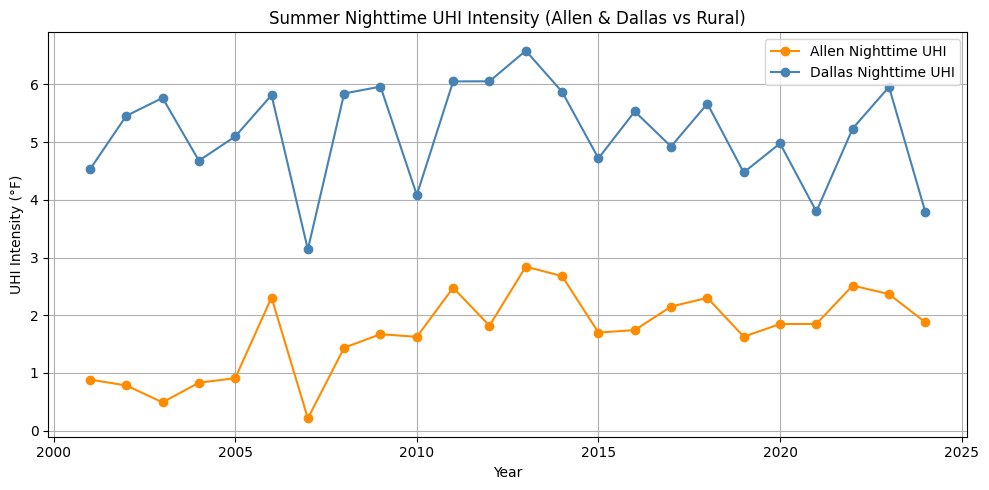

In [41]:
# Plot: Daytime UHI
plt.figure(figsize=(10, 5))
plt.plot(df['Year'], df['Allen_UHI_Day'], 'o-', label='Allen Daytime UHI', color='crimson')
plt.plot(df['Year'], df['Dallas_UHI_Day'], 'o-', label='Dallas Daytime UHI', color='navy')
plt.title('Summer Daytime UHI Intensity (Allen & Dallas vs Rural)')
plt.xlabel('Year')
plt.ylabel('UHI Intensity (°F)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot: Nighttime UHI
plt.figure(figsize=(10, 5))
plt.plot(df['Year'], df['Allen_UHI_Night'], 'o-', label='Allen Nighttime UHI', color='darkorange')
plt.plot(df['Year'], df['Dallas_UHI_Night'], 'o-', label='Dallas Nighttime UHI', color='steelblue')
plt.title('Summer Nighttime UHI Intensity (Allen & Dallas vs Rural)')
plt.xlabel('Year')
plt.ylabel('UHI Intensity (°F)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

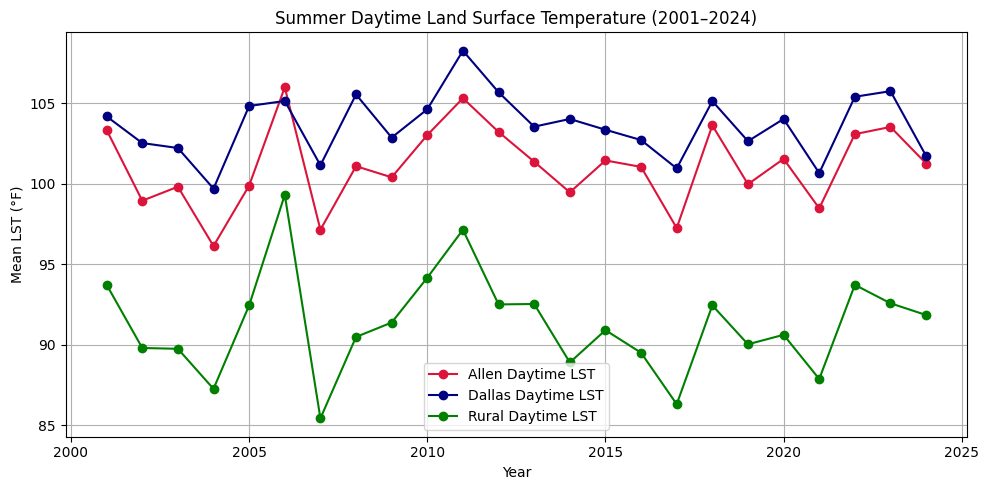

In [42]:
# Plot: Raw Summer Daytime LST for All Three Locations
plt.figure(figsize=(10, 5))
plt.plot(df['Year'], df['Allen_Day'], 'o-', label='Allen Daytime LST', color='crimson')
plt.plot(df['Year'], df['Dallas_Day'], 'o-', label='Dallas Daytime LST', color='navy')
plt.plot(df['Year'], df['Rural_Day'], 'o-', label='Rural Daytime LST', color='green')
plt.title('Summer Daytime Land Surface Temperature (2001–2024)')
plt.xlabel('Year')
plt.ylabel('Mean LST (°F)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
df['Allen_Dallas_Day'] = df['Allen_Day'] - df['Dallas_Day']
# df['Allen_Rural_Day'] = df['Allen_Day'] - df['Rural_Day']
# df['Dallas_Rural_Day'] = df['Dallas_Day'] - df['Rural_Day']

In [44]:
df

,Year,Allen_Day,Dallas_Day,Rural_Day,Allen_Night,Dallas_Night,Rural_Night,Allen_UHI_Day,Dallas_UHI_Day,Allen_UHI_Night,Dallas_UHI_Night,Allen_Dallas_Day
0,2001,103.342863,104.187714,93.721949,76.685980,80.329057,75.802102,9.620913,10.465764,0.883878,4.526955,-0.844851
1,2002,98.947107,102.531117,89.791789,75.036580,79.710142,74.254215,9.155318,12.739328,0.782365,5.455926,-3.584010
2,2003,99.816634,102.224252,89.740882,74.495440,79.773832,74.006585,10.075752,12.483370,0.488855,5.767247,-2.407618
3,2004,96.130110,99.698269,87.252066,74.486167,78.335466,73.656379,8.878043,12.446202,0.829788,4.679087,-3.568159
4,2005,99.891642,104.837250,92.441851,76.243764,80.434538,75.336060,7.449792,12.395399,0.907704,5.098478,-4.945607
5,2006,105.996926,105.147242,99.313083,77.681444,81.189882,75.375018,6.683843,5.834159,2.306426,5.814864,0.849684
6,2007,97.139929,101.150650,85.417763,74.685811,77.614671,74.474051,11.722166,15.732886,0.211760,3.140620,-4.010721
7,2008,101.093409,105.552468,90.477921,76.766122,81.173089,75.329745,10.615488,15.074547,1.436377,5.843344,-4.459059
8,2009,100.402211,102.873090,91.372912,77.171745,81.464381,75.500593,9.029299,11.500178,1.671152,5.963788,-2.470880
9,2010,103.028187,104.631266,94.161647,79.438309,81.898568,77.813641,8.866540,10.469620,1.624669,4.084927,-1.603079


Allen is very gradually closing the LST gap with downtown Dallas at the speed of 0.038 F/year. However, the R square is very weak, suggesting the upward trend might be due to other factors such as local weather anomalies.

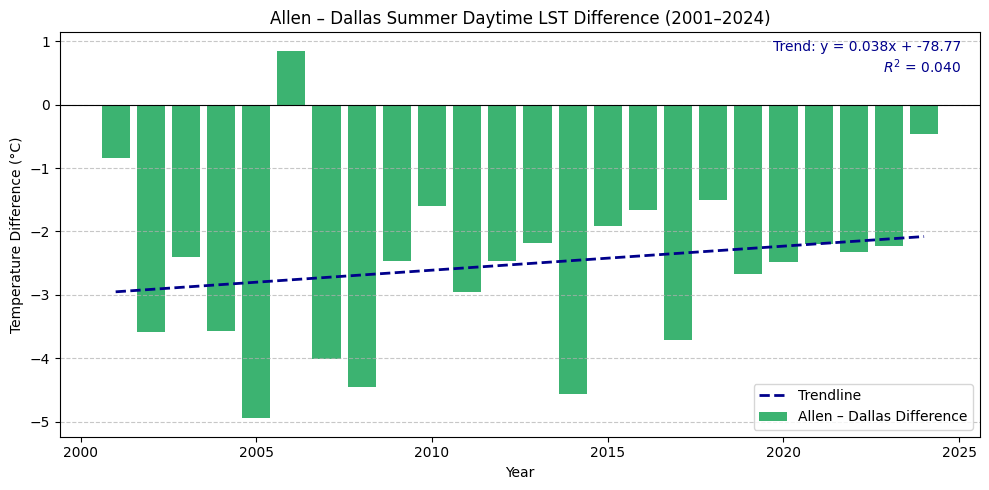

In [45]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data
X = df['Year'].values.reshape(-1, 1)
y = df['Allen_Dallas_Day'].values

# Fit regression model
model = LinearRegression().fit(X, y)
trend = model.predict(X)
slope = model.coef_[0]
intercept = model.intercept_
r_squared = model.score(X, y)

# Plot bar chart
plt.figure(figsize=(10, 5))
plt.bar(df['Year'], y, color='mediumseagreen', label='Allen – Dallas Difference')
plt.plot(df['Year'], trend, '--', color='darkblue', linewidth=2, label='Trendline')
plt.axhline(0, color='black', linewidth=0.8)

# Display regression equation in the top-right of the chart area
equation_text = f'Trend: y = {slope:.3f}x + {intercept:.2f}\n$R^2$ = {r_squared:.3f}'
plt.text(0.98, 0.98, equation_text,
         ha='right', va='top',
         transform=plt.gca().transAxes,
         fontsize=10, color='darkblue')

# Final styling
plt.title('Allen – Dallas Summer Daytime LST Difference (2001–2024)')
plt.xlabel('Year')
plt.ylabel('Temperature Difference (°C)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


# Visualizing Heatmap

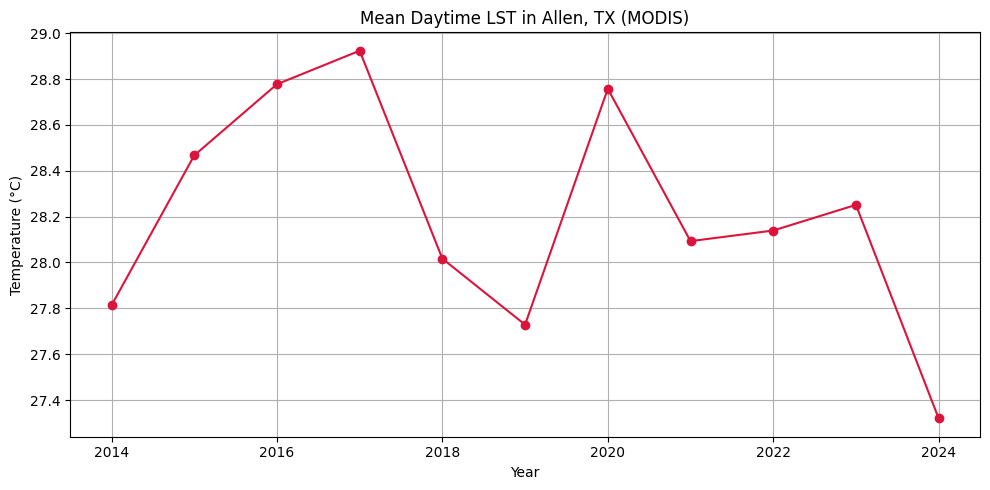

In [5]:
# Define Allen bounding box
allen_bbox = ee.Geometry.BBox(-96.7140, 33.0700, -96.6240, 33.1400)

# Load MODIS LST Day 1km data
modis_lst = ee.ImageCollection('MODIS/061/MOD11A2') \
    .filterDate('2014-01-01', '2024-12-31') \
    .select('LST_Day_1km') \
    .filterBounds(allen_bbox)

scale_factor = 0.02

# Yearly average LST
def yearly_mean(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, 'year')
    lst_year = modis_lst.filterDate(start, end).mean()
    lst_scaled = lst_year.multiply(scale_factor).subtract(273.15)  # Kelvin to Celsius
    return lst_scaled.set('year', year)

years = list(range(2014, 2025))
yearly_lst = ee.ImageCollection([yearly_mean(y) for y in years])

def extract_mean(img):
    stats = img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=allen_bbox,
        scale=1000,
        maxPixels=1e9
    )
    return ee.Feature(None, {
        'year': img.get('year'),
        'mean_LST_Celsius': stats.get('LST_Day_1km')
    })

lst_stats = yearly_lst.map(extract_mean)
lst_fc = ee.FeatureCollection(lst_stats)

# Download data to client side
years_list = years
lst_list = lst_fc.aggregate_array('mean_LST_Celsius').getInfo()

# Plot
df = pd.DataFrame({'Year': years_list, 'Mean_LST_Celsius': lst_list})
plt.figure(figsize=(10, 5))
plt.plot(df['Year'], df['Mean_LST_Celsius'], marker='o', color='crimson')
plt.title('Mean Daytime LST in Allen, TX (MODIS)')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.tight_layout()
plt.show()


The image looks blocky and lacks fine detail due to 1km resolution
Allen as fairly uniform and warm, which aligns with July weather in North Texas.

MODIS LST (1 km resolution) is often too coarse to capture meaningful intra-city temperature variation in a small area like Allen

In [8]:
# Install required packages (only needed in Colab or a fresh environment)
# !pip install earthengine-api folium

# import ee
import folium
# import geemap

# Authenticate and initialize
# ee.Authenticate()
# ee.Initialize()

# Allen, TX bounding box
allen_bbox = ee.Geometry.BBox(-96.7140, 33.0700, -96.6240, 33.1400)

# Load MODIS LST image for July 2023
modis_lst = ee.ImageCollection('MODIS/061/MOD11A2') \
    .filterDate('2023-04-01', '2023-04-30') \
    .select('LST_Day_1km') \
    .mean() \
    .clip(allen_bbox)

# MODIS LST scale factor
scale_factor = 0.02

# Convert to Celsius
lst_celsius = modis_lst.multiply(scale_factor).subtract(273.15)

# Visualization parameters
vis_params = {
    'min': 20,    # degrees Celsius
    'max': 45,
    'palette': [
        '040274', '040281', '0502a3', '0502b8', '0610d4',
        '071ce0', '081fff', '0a34ff', '0b4cff', '0c66ff',
        '0d80ff', '0e99ff', '10b2ff', '12ccff', '14e5ff',
        '16ffff', '29fff3', '3bffd9', '4dffbf', '60ffaa',
        '72ff95', '84ff80', '96ff6a', 'a8ff55', 'bbff3f',
        'cdff2a', 'dfff14', 'f2ff00', 'ffff00'
    ]
}

# Create an interactive map centered at Allen, TX
map_ = geemap.Map(center=[33.105, -96.669], zoom=12)
map_.addLayer(lst_celsius, vis_params, 'LST April 2023 (Allen)')
map_.add_colorbar(vis_params['palette'], vmin=20, vmax=45, label='Temperature (°C)')
map_


Map(center=[33.105, -96.669], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDat…

In [11]:
# import ee
# import geemap
import ipywidgets as widgets
from IPython.display import display

# ee.Initialize()  # Uncomment if not using geemap auto-auth

# Allen bounding box
allen_bbox = ee.Geometry.BBox(-96.7140, 33.0700, -96.6240, 33.1400)

# Load MODIS LST (July 2022)
modis = ee.ImageCollection('MODIS/061/MOD11A2') \
    .filterDate('2022-04-01', '2022-04-30') \
    .select('LST_Day_1km') \
    .mean().multiply(0.02).subtract(273.15)  # Convert from Kelvin to Celsius

# Load NLCD 2021
nlcd = ee.ImageCollection("USGS/NLCD_RELEASES/2021_REL/NLCD") \
    .filter(ee.Filter.eq('system:index', '2021')) \
    .first().select('landcover')

# NLCD color palette and class names
nlcd_palette = [
    '466b9f',  # Open Water
    'dec5c5',  # Developed, Open Space
    'd99282',  # Developed, Low Intensity
    'eb0000',  # Developed, Medium Intensity
    '8000ff',  # Developed, High Intensity
    'b3ac9f',  # Barren Land
    '68ab5f',  # Deciduous Forest
    '1c5f2c',  # Evergreen Forest
    'b5c58f',  # Mixed Forest
    'af963c',  # Shrub/Scrub
    'cdc9c9',  # Grassland/Herbaceous
    'fb9f3a',  # Pasture/Hay
    'dcd939',  # Cultivated Crops
    'ab6c28',  # Woody Wetlands
    'b8d9eb'   # Emergent Herbaceous Wetlands
]

nlcd_labels = [
    'Open Water',
    'Developed, Open Space',
    'Developed, Low Intensity',
    'Developed, Medium Intensity',
    'Developed, High Intensity',
    'Barren Land',
    'Deciduous Forest',
    'Evergreen Forest',
    'Mixed Forest',
    'Shrub/Scrub',
    'Grassland/Herbaceous',
    'Pasture/Hay',
    'Cultivated Crops',
    'Woody Wetlands',
    'Emergent Herbaceous Wetlands'
]

# Visualization parameters
lst_vis = {
    'min': 20,
    'max': 40,
    'palette': ['blue', 'green', 'yellow', 'orange', 'red']
}

nlcd_vis = {
    'min': 11,
    'max': 95,
    'palette': nlcd_palette
}

# Initialize map
Map = geemap.Map(center=[33.105, -96.669], zoom=12)
Map.addLayer(modis.clip(allen_bbox), lst_vis, 'MODIS LST (July 2022)')
Map.addLayer(nlcd.clip(allen_bbox), nlcd_vis, 'NLCD 2021', opacity=0.5)
Map.addLayer(allen_bbox, {'color': 'black'}, 'Allen Bounding Box', False)

# Add LST color bar
Map.add_colorbar(vis_params=lst_vis, label='Land Surface Temperature (°C)', layer_name='MODIS LST')

# Add NLCD legend
legend_dict = dict(zip(nlcd_labels, nlcd_palette))
Map.add_legend(title='NLCD Land Cover (2021)', legend_dict=legend_dict)

Map

Map(center=[33.105, -96.669], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDat…

In [24]:
# import ee
# import geemap

# Optional: ee.Initialize()  # Commented out if running in Colab or already initialized

# Define Allen bounding box
allen_bbox = ee.Geometry.BBox(-96.7140, 33.0700, -96.6240, 33.1400)

# Load Landsat 8 Collection 2, Tier 1, Level-2 data
landsat8 = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
    .filterBounds(allen_bbox) \
    .filterDate('2022-07-01', '2022-07-31') \
    .filter(ee.Filter.lt('CLOUD_COVER', 20)) \
    .median()

# Convert brightness temperature from Kelvin to Celsius (Band: ST_B10)
lst_kelvin = landsat8.select('ST_B10')
lst_celsius = lst_kelvin.multiply(0.00341802).add(149.0).subtract(273.15)
lst_celsius_clipped = lst_celsius.clip(allen_bbox)

# Define visualization parameters
vis_params = {
    'min': 0,
    'max': 50,
    'palette': ['040274', '2080b0', '8cd7c3', 'ffffbf', 'ffaa00', 'ff0000']
}

# Create interactive map and add layer
Map = geemap.Map(center=[33.105, -96.669], zoom=13)
Map.addLayer(lst_celsius_clipped, vis_params, 'LST (Celsius) Clipped')
Map.addLayer(allen_bbox, {}, 'Allen Bounding Box')

# Add layer control and display
Map.add_colorbar(vis_params, label='Land Surface Temp (°C)', layer_name='LST (Celsius) Clipped')
Map


Map(center=[33.105, -96.669], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDat…